Ejemplo del libro de Ciaburro: https://github.com/PacktPublishing/Hands-On-Simulation-Modeling-with-Python-Second-Edition

In [1]:
import matplotlib.pyplot as plt
from random import random

In [2]:
class SchAgent:

    def __init__(self, type):
        self.type = type
        self.ag_location()

    def ag_location(self):
        self.location = random(), random()

    def euclidean_distance(self, new):
        eu_dist = ((self.location[0] - new.location[0])**2 \
                    + (self.location[1] - new.location[1])**2)**(1/2)
        return eu_dist

    def satisfaction(self, agents):
        eu_dist = []    
        for agent in agents:
            if self != agent:
                eu_distance = self.euclidean_distance(agent)
                eu_dist.append((eu_distance, agent))
        eu_dist.sort()
        neigh_agent = [agent for k, agent in eu_dist[:neigh_num]]
        neigh_itself = sum(self.type == agent.type for agent in neigh_agent)
        return neigh_itself >= neigh_threshold

    def update(self, agents):
        while not self.satisfaction(agents):
            self.ag_location()

In [5]:
def grid_plot(agents, step):
    x_A, y_A = [], []
    x_B, y_B = [], []
    for agent in agents:
        x, y = agent.location
        if agent.type == 0:
            x_A.append(x)
            y_A.append(y)
        else:
            x_B.append(x)
            y_B.append(y)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x_A, y_A, '^', markerfacecolor='b',markersize= 6)
    ax.plot(x_B, y_B, 'o', markerfacecolor='r',markersize= 6)
    ax.set_title(f'Step number = {step}')
    plt.show()

Step number =  0


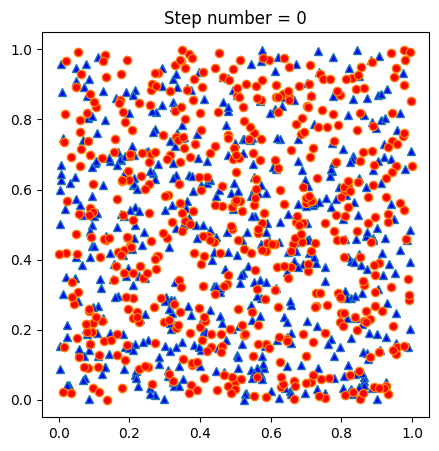

Step number =  1


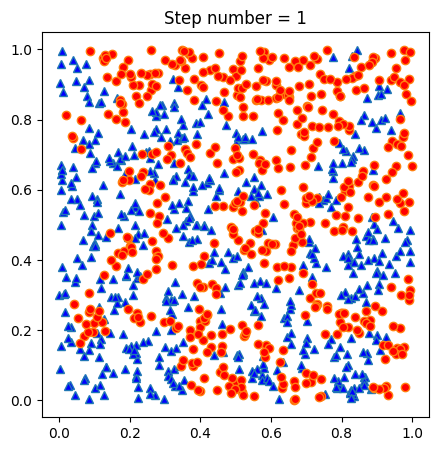

Step number =  2


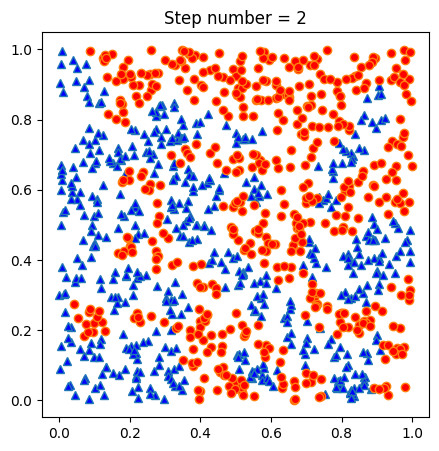

Step number =  3


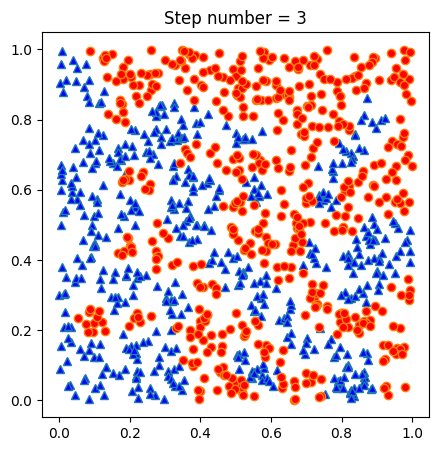

Step number =  4


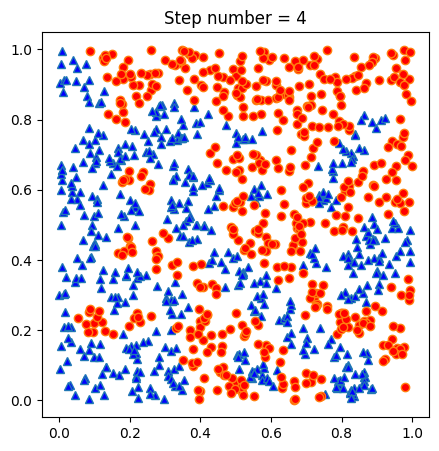

Step number =  5


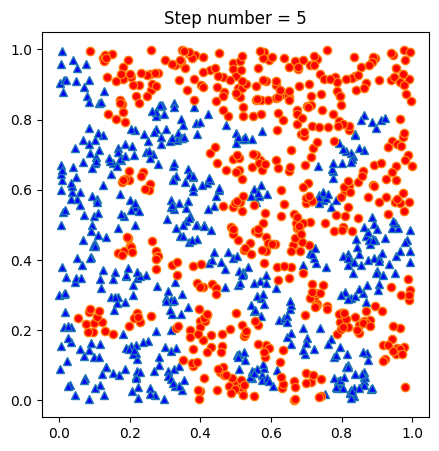

Satisfied agents with 50.0 % of similar neighbors


In [6]:
num_agents_A = 500
num_agents_B = 500
neigh_num = 8      
neigh_threshold = 4 

agents = [SchAgent(0) for i in range(num_agents_A)]
agents.extend(SchAgent(1) for i in range(num_agents_B))

step = 0
k=0
while (k<(num_agents_A + num_agents_B)):
    print('Step number = ', step)
    grid_plot(agents, step)
    step += 1
    k=0
    for agent in agents:
        old_location = agent.location
        agent.update(agents)
        if agent.location == old_location:
            k=k+1 
else:
    print(f'Satisfied agents with {neigh_threshold/neigh_num*100} \
% of similar neighbors')